Nombre total d'exemples valides : 99

LABEL ACCURACY


,Metric,Score (%)
0,Label Accuracy,71.72



CONFUSION MATRIX (Validation Type)


Prediction,exact_match,invented_hypothesis,missing_hypothesis,valid_implication,All
Ground Truth,,,,,
exact_match,14,0,3,13,30
invented_hypothesis,0,16,3,10,29
missing_hypothesis,5,5,9,3,22
multiple_missing,1,4,2,2,9
stronger_hypothesis,2,4,0,3,9
All,22,29,17,31,99


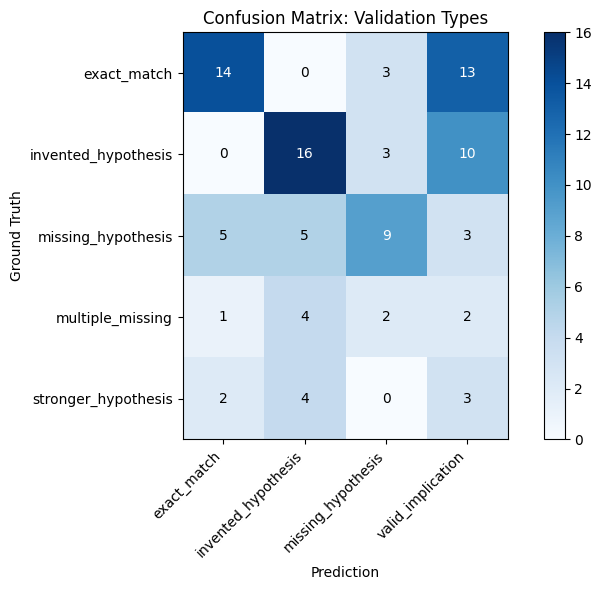


GLOBAL VALIDATION TYPE ACCURACY


,Metric,Score (%),Support
0,Global Validation Type Accuracy,39.39,99



ACCURACY PER VALIDATION TYPE


,Validation Type,Support,Accuracy (%)
1,invented_hypothesis,29,55.17
0,exact_match,30,46.67
2,missing_hypothesis,22,40.91
3,multiple_missing,9,0.00
4,stronger_hypothesis,9,0.00


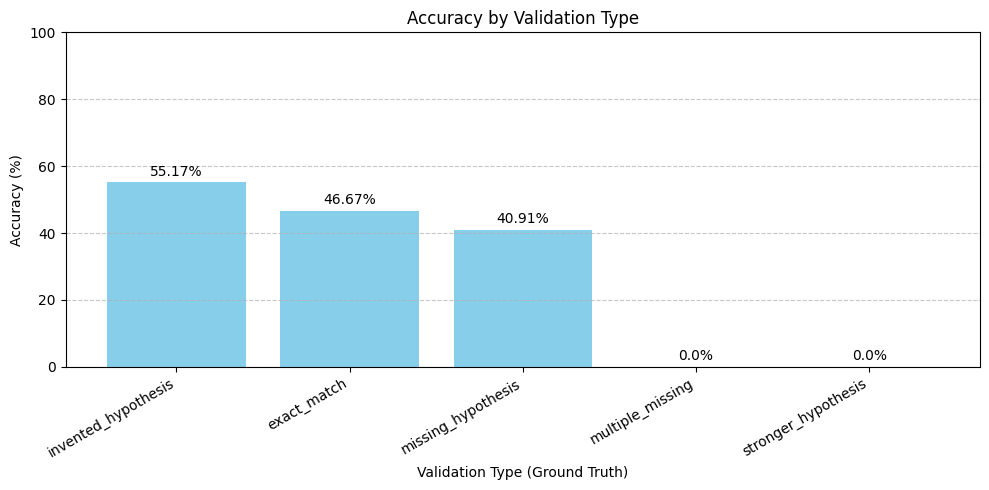

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# Chargement
# ==========================================================

df = pd.read_csv("/kaggle/input/datasets/mathurasanthalingam/benchmark-results/benchmark_results.csv")
df.columns = df.columns.str.strip()

# On ne garde que les lignes où le JSON a bien été parsé
df = df[df["parse_error"].isna()].copy()

print("="*70)
print(f"Nombre total d'exemples valides : {len(df)}")
print("="*70)

# ==========================================================
# 1. LABEL ACCURACY (Correct vs Incorrect)
# ==========================================================

label_accuracy = (df["ground_truth_label"] == df["prediction_label"]).mean()

summary = pd.DataFrame({
    "Metric": ["Label Accuracy"],
    "Score (%)": [round(label_accuracy * 100, 2)]
})

print("\n==============================")
print("LABEL ACCURACY")
print("==============================")
display(summary)

# ==========================================================
# 2. MATRICE DE CONFUSION (Validation Type)
# ==========================================================
# On remplace les NaN par "none" pour éviter que pandas ne les ignore
gt_val = df["ground_truth_validation"].fillna("none")
pred_val = df["prediction_validation"].fillna("none")

confusion = pd.crosstab(
    gt_val,
    pred_val,
    rownames=["Ground Truth"],
    colnames=["Prediction"],
    margins=True
)

print("\n==============================")
print("CONFUSION MATRIX (Validation Type)")
print("==============================")
display(confusion)

# --------- Visualisation de la matrice ---------
plt.figure(figsize=(8, 6))
# On enlève la ligne/colonne 'All' (margins) pour le graphique
conf_plot = confusion.iloc[:-1, :-1]

plt.imshow(conf_plot, cmap="Blues")

plt.xticks(range(len(conf_plot.columns)), conf_plot.columns, rotation=45, ha="right")
plt.yticks(range(len(conf_plot.index)), conf_plot.index)

plt.xlabel("Prediction")
plt.ylabel("Ground Truth")
plt.title("Confusion Matrix: Validation Types")

for i in range(len(conf_plot.index)):
    for j in range(len(conf_plot.columns)):
        plt.text(j, i, conf_plot.iloc[i, j], ha="center", va="center", color="black" if conf_plot.iloc[i, j] < conf_plot.values.max()/2 else "white")

plt.colorbar()
plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

# ==========================================================
# 3. VALIDATION TYPE ACCURACY GLOBALE
# ==========================================================

val_accuracy = (gt_val == pred_val).mean()

summary_val = pd.DataFrame({
    "Metric": ["Global Validation Type Accuracy"],
    "Score (%)": [round(val_accuracy * 100, 2)],
    "Support": [len(df)]
})

print("\n==============================")
print("GLOBAL VALIDATION TYPE ACCURACY")
print("==============================")
display(summary_val)

# ==========================================================
# 4. ACCURACY PAR TYPE DE VALIDATION (Le graphique)
# ==========================================================

results = []
# On parcourt tous les types de vérité terrain
for val_type in sorted(gt_val.unique()):
    subset = df[gt_val == val_type]
    if len(subset) > 0:
        # L'accuracy pour ce type spécifique
        acc = (subset["ground_truth_validation"] == subset["prediction_validation"]).mean()
        
        results.append({
            "Validation Type": val_type,
            "Support": len(subset),
            "Accuracy (%)": round(acc * 100, 2)
        })

results_df = pd.DataFrame(results).sort_values("Accuracy (%)", ascending=False)

print("\n==============================")
print("ACCURACY PER VALIDATION TYPE")
print("==============================")
display(results_df)

# --------- Visualisation en Barres ---------
plt.figure(figsize=(10, 5))

plt.bar(results_df["Validation Type"], results_df["Accuracy (%)"], color="skyblue")
plt.ylim(0, 100)
plt.ylabel("Accuracy (%)")
plt.xlabel("Validation Type (Ground Truth)")
plt.title("Accuracy by Validation Type")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Ajouter les valeurs au-dessus des barres
for i, acc in enumerate(results_df["Accuracy (%)"]):
    plt.text(i, acc + 2, f"{acc}%", ha="center")

plt.tight_layout()
plt.savefig("accuracy_by_type.png", dpi=300, bbox_inches="tight")
plt.show()